# Exploratory Data Analysis of Reports

This notebook contains exploratory data analysis of the Annual Reports and Accounts.

It analyses the data that has already been processed to an interim stage, meaning the forewords and metadata have been extracted from the PDF reports into a pandas DataFrame, that was then saved as a .parquet file. 

Here I explore the distribution of author types and years, to determine what subset of the data would be appropriate for the project.

In [1]:
# import packages
import pandas as pd

# import self made functions
from src.analysis.plotting import plot_years_authors
from src.preprocessing.cleaning import merge_authors, select_years

## Loading in the Data

I begin by loading in the and presenting counts of forewords by author type and year in a table and bar chart.

Author types include:
- sos - authored by the Secretary of State or equivalent political position within a department
- min - authored by a Junior Minister or equivalent political position within a department
- ps - authored by a Permanent Secretary or equivalent senior civil servant position within a department, with the suffix 1 and 2 denoting multiple forewords by different Permanent Secretaries
- joint - co-authored by a politician and civil servant together

Three years of data were collected, with 2023 denoting reports written covering the 2022 to 2023 financial year, 2024 denoting reports written covering the 2023 to 2024 financial year and 2025 denoting reports written covering the 2024 to 2025 financial year. 

In [2]:
# load in interim data
data = pd.read_parquet('data/interim/df.parquet', engine='fastparquet')

In [3]:
# present data in a table
data.groupby(['year', 'author_type']).size().unstack(fill_value=0)

author_type,joint,min,ps,ps1,ps2,sos
year,,,,,,
2023,1,3,11,0,0,9
2024,0,1,15,0,0,0
2025,0,3,14,1,1,12


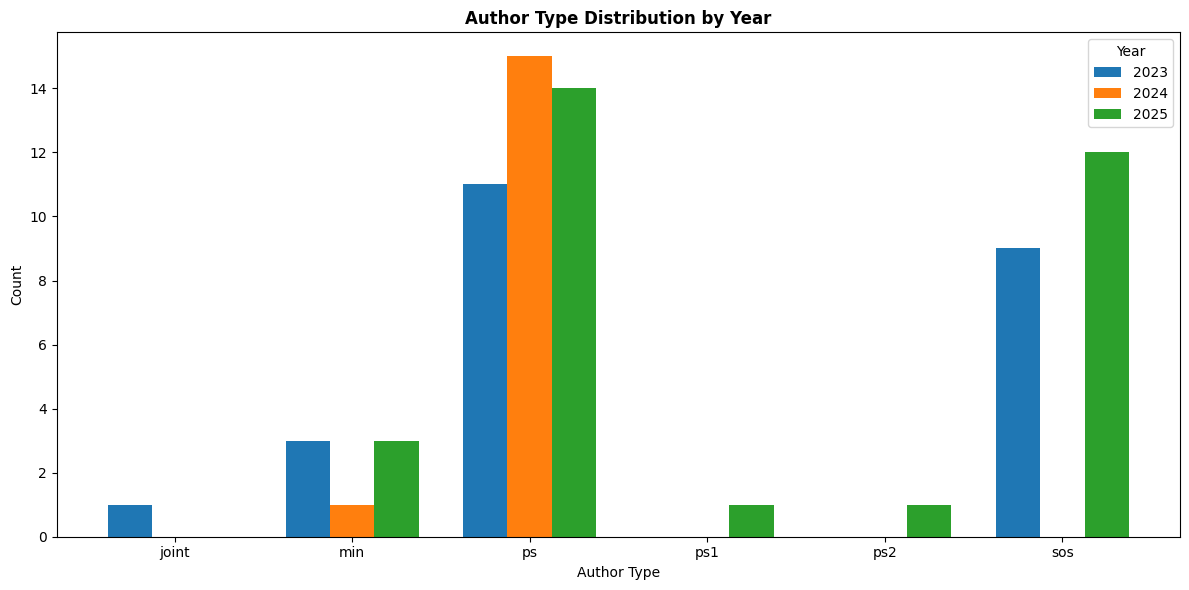

In [4]:
# plot bar chart
plot_years_authors(data)

As can be seen from the plot, very few politician-authored forewords are available for the 2023 to 2024 financial year, due to the reports being published in the pre-election period, which restricts commentary. From manual inspection, forewords written by civil servants were also very brief, so I will drop this year's data from the analysis.

In addition, to simplify the analysis, I will combine sos and min into 'pol' for politician-authored forewords and ps, ps1 and ps2 into 'cs' for civil servant-authored forewords. I will drop the joint foreword as I will not be able to separate text (and therefore emotiveness) between politican and civil servant.

## Data Cleaning
I now present the distribution with the author types and years cleaned.

In [7]:
# merge authors and present new distribution
data_reduced = merge_authors(data)
data_reduced.groupby(['year', 'author_type']).size().unstack(fill_value=0)

author_type,cs,pol
year,,
2023,11,12
2024,15,1
2025,16,15


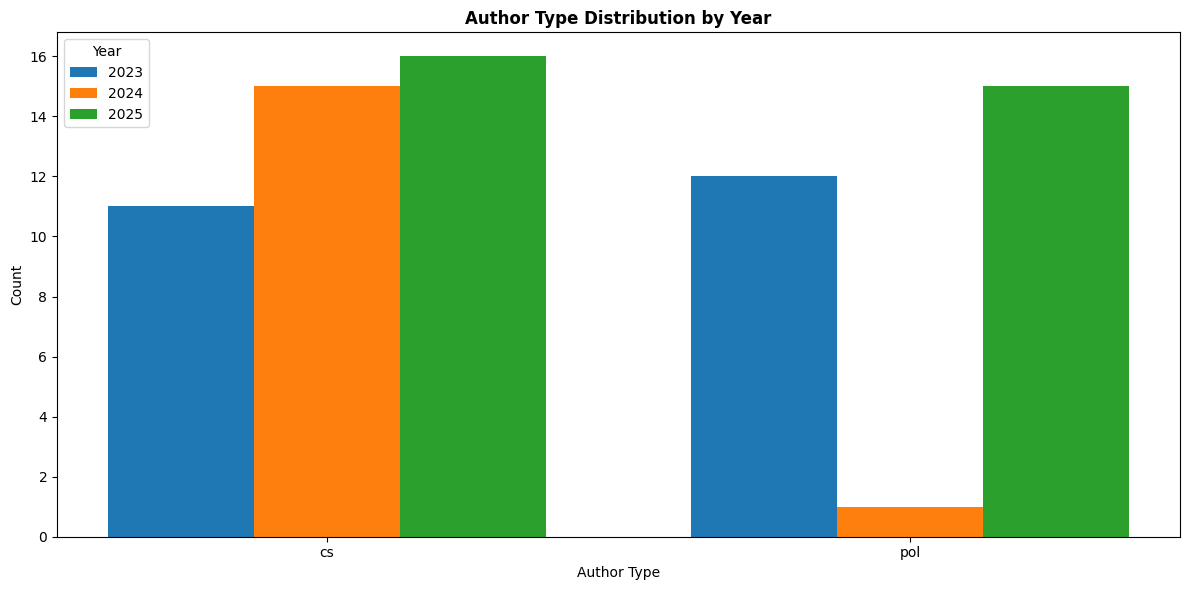

In [6]:
# plot bar chart of data with author types merged
plot_years_authors(data_reduced)

In [7]:
# drop 2024 and present counts by author type and year
years = [2023, 2025]
data3 = select_years(data_reduced, years)
data3.groupby(['year', 'author_type']).size().unstack(fill_value=0)

author_type,cs,pol
year,,
2023,11,12
2025,16,15


In [8]:
# tablify distribution by department
data3.groupby(['year', 'author_type', 'department']).size().unstack(fill_value=0)

department        co  dbt  dcms  defra  desnz  dfe  dft  dhsc  dsit  dwp  \
year author_type                                                           
2023 cs            1    0     1      0      0    1    1     1     0    1   
     pol           1    0     1      0      0    1    1     0     0    1   
2025 cs            1    1     1      1      1    1    2     1     1    1   
     pol           2    0     1      0      1    1    1     0     1    1   

department        fcdo  hmt  ho  mhclg  mod  moj  
year author_type                                  
2023 cs              0    1   1      1    1    1  
     pol             2    1   1      1    1    1  
2025 cs              0    1   1      1    1    1  
     pol             2    1   1      1    1    1

In [9]:
# print counts by year and author type
counts = data3.groupby(['year', 'author_type', 'department']).size().unstack(fill_value=0)
depts = {}
not_depts = {}
yrs = counts.index.get_level_values(0).unique()

for yr in yrs:
    depts[yr] = []
    not_depts[yr] = []
    for col in counts.columns:
        if counts.loc[(yr, 'cs'), col] >= 1 and counts.loc[(yr, 'pol'), col] >= 1:
            depts[yr].append(col)
        else:
            not_depts[yr].append(col)

for yr in yrs:
    print(f'{yr}:\n{len(depts[yr])} departments have forewords by both cs and pols,',
          '\n'
          f'{len(not_depts[yr])} departments do not have both.',
          '\n'
          f'There are {len(counts.columns)} departments in {yr} in total.')

2023:
10 departments have forewords by both cs and pols, 
6 departments do not have both. 
There are 16 departments in 2023 in total.
2025:
12 departments have forewords by both cs and pols, 
4 departments do not have both. 
There are 16 departments in 2025 in total.


I now have 54 forewords, 27 authored by politicians and 27 authored by civil servants. 23 come from the 2022 to 2023 financial year reports and 31 come from the 2024 to 2025 financial year reports. 

Not all departments have reports authored by both a civil servant and a politician in that year. For simplification, I will not consider reports at the department level, instead grouping by year and author type. This will lose the benefits of within-document comparison (that could control for other factors in how authors write, such as the information they were presented and department goals), but enable more of the dataset to be used.

## Visual Text Inspection

I also visually inspected the PDFs to identify formatting features.
I identified the below characteristics that I would need to be aware of when processing the text:

* Headers, Footers, Page Numbers
* Author name and job description listed at the start or end of the foreword
* Titles, Headings, Subheadings
* Typos, including a missing space between a full stop and the next sentence
* Multi-column layouts creating very short sentences (e.g. 5 words) per line

I determined the following cleaning steps would be necessary to process the text.
I first process the text by line.
* To remove page numbers:
    * I remove lines that are only digits or of the form 'page X' or 'page X | more text'.
* To remove headers, footers, titles etc.
    * I exclude lines that are fewer than 4 words and do not end in punctuation (acknowleding that some multi-column layout text maybe affected).
    * I exclude lines that are in all CAPS but greater than 1 word (to not affect capitalisation used in the body of the text).
    * I exclude lines in the format of '{department name} {annual report} {financial-year}'.
    * I exclude short lines surrounded by blank space i.e. empty lines either side.

After this, I rejoin the text into a single string to process sentences, replicating the steps in Gennaro & Ash (2022). I remove the first two sentences and last sentence as a final buffer against failed cleaning attempts, acknowledging the loss of potential data. Further details are in the project report.